# Lab 3: Mine Crafting


As with previous labs, be sure to submit only the `lab3.ipynb` and `lab3.html` version of the lab in your github `Lab3` folder. No more, and no less.

## Introduction

Imagine you are a scientist for a mining company that operates a vertical mine at the Earth's
equator. This is one of the deepest mines on Earth; it's roughly 4 km to the bottom of the shaft.
Your boss proposes to measure the vertical depth of the shaft by dropping a 1 kg test mass and
accurately measuring the time to hit the bottom.

You will be guided in your investigations below and submit your report in the form of this notebook. Be sure to be quantitative in nature, produce highly polished plots, with appropriate titles, units, etc.


A table of relevant physical constants is below. Good luck!

| Quantity | Value |
|----------|-------|
|  Gravitational Constant ($G$)        |  $6.6743 \times 10^{-11}$ m$^3$/kg/s$^2$  | 
|  Gravitational Acceleration ($g_o$)  |  9.81 m/s$^2$ (approximate) | 
|  Mass of the Earth ($M_{\oplus}$)    |  $5.972 \times 10^{24}$ kg      | 
|  Mass of the Moon ($M_{m}$)          |  $7.35 \times 10^{22}$ kg     | 
|  Radius of the Earth ($R_{\oplus}$)  |  6378.1 km     | 
|  Radius of the Moon ($R_{m}$)        |   1738.1 km    | 
|  Earth's Rotation Rate at the Equator| $7.272 \times 10^{-5} $ rad/s  | 

## Part 1: The Ideal Case

In this section and the following sections, we calculate the time for the 1 kg test mass to reach the bottom of the mineshaft under a series of increasingly complex assumptions. Remember that a projectile experiencing a constant gravitational force, plus a drag force, obeys the following second
order differential equation:

$$
\frac{d^2y}{dt^2} = -g + \alpha \left| \frac{dy}{dt} \right|^{\gamma}
\tag{1}
$$



where $t$ is time, $y$ is the height, $g$ is the gravitational acceleration,
$\alpha$ is the drag coefficient, and $\gamma$ is the speed dependence
of the drag. For example, for $\gamma=2$, the drag force grows proportionally
to the speed *squared*.  **Hint**: pay particular attention to the sign
conventions in your implementation! The drag, by definition, should *oppose*
the direction of motion.

1. First, make a simple calculation of how long a test mass would 
            take to reach the bottom of the 4km shaft assuming no drag. This is the simple
            free-fall algebraic expression you know from PHYS 171.

2. Next, reduce (1) into a *system* of coupled
            first order differential equations by setting the velocity $v = dy/dt$.

3. Numerically solve (1) using `solve_ivp` assuming $\alpha=0$.
            Plot the position and velocity as a function of time.                              
            Draw a horizontal dashed line at the depth of the bottom of the shaft,
            to make it easy to see.
            Make the plot look nice, including displaying the position on the left axes,
            and plotting the velocity on a second right axis, using matplotlib `twinx`
            capability.        
   In your notebook, label this figure clearly as **Figure 1**.

4. Using the `events` detection capability of `solve_ivp`,
            calculate the time at which the mass hits the bottom of the shaft
            in the case of zero drag ($\alpha=0$). Compare this to your analytic calculation
            and discuss any differences you might see.


In [1]:
#show
# James Watt 2026 UMD PHYS 265 LAB 3
# imports and constants for the whole lab

import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as sc

from scipy.integrate import solve_ivp, quad
from scipy.fft import rfft, rfftfreq
from numpy.typing import ArrayLike

#___Constants and Such___#

G = 6.6743e-11                      # m^3 / kg / s^2
g0 = 9.81                           # m / s^2, surface gravity approximation
M_earth = 5.972e24                   # kg
M_moon = 7.35e22                     # kg
R_earth = 6378.1e3                   # m
R_moon = 1738.1e3                    # m
Omega_earth = 7.272e-5               # rad / s
shaft_depth = 4.0e3                  # m
m_test = 1.0                         # kg

terminal_speed = 50.0                # m / s, sky-diver-esque shape terminal vel
gamma_drag = 2.0
alpha_terminal = g0 / terminal_speed**gamma_drag

print(f"Earth radius: {R_earth:.3e} m")
print(f"Shaft depth: {shaft_depth:.1f} m")
print(f"Drag alpha from terminal speed of 50 m/s: {alpha_terminal:.5e} 1/m")

Earth radius: 6.378e+06 m
Shaft depth: 4000.0 m
Drag alpha from terminal speed of 50 m/s: 3.92400e-03 1/m


In [2]:
# Part 1: analytic no-drag free fall time

analytic_time = np.sqrt(2 * shaft_depth / g0)
analytic_impact_speed = g0 * analytic_time

print(f"Analytic no-drag fall time = {analytic_time:.3f} s")
print(f"Analytic impact speed = {analytic_impact_speed:.3f} m/s")

Analytic no-drag fall time = 28.557 s
Analytic impact speed = 280.143 m/s


For the first model, I used $y=0$ at the surface and $y=-4000$ m at the bottom of the shaft. With no drag and constant $g$, the motion is the standard PHYS 171 free-fall result, so the only numerical error should come from the ODE solver tolerances.

Numerical event fall time = 28.556862 s
Analytic fall time        = 28.556862 s
Percent difference       = 0.000e+00 %


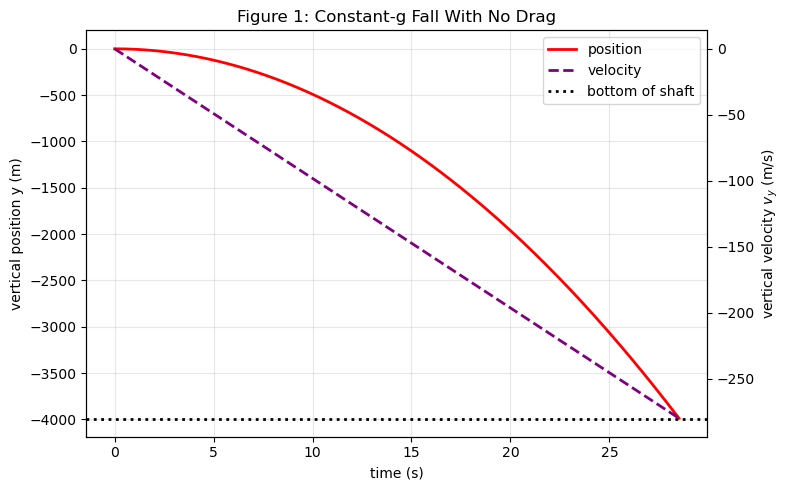

In [24]:
def drag_acceleration(v: float | np.ndarray, alpha: float, gamma: float = 2.0) -> float | np.ndarray:
    """
    Return the drag acceleration for a 1D velocity.
    The minus sign makes the drag force oppose the current direction of motion.
    """
    return -alpha * np.abs(v)**gamma * np.sign(v)


def constant_g_rhs(t: float, state: ArrayLike, alpha: float = 0.0, gamma: float = 2.0) -> list[float]:
    """
    Coupled first order equations for the simple vertical fall.
    state[0] = y, measured upward from the surface, in m
    state[1] = v_y, in m/s
    """
    y, vy = state
    ay = -g0 + drag_acceleration(vy, alpha, gamma)
    return [vy, ay]


def hit_bottom_event(t: float, state: ArrayLike, *args) -> float:
    """Event function that becomes zero when y = -shaft_depth."""
    #print(f"Hello,{state[0]}") detects when position reaches shaft depth, takes advantage of negative sign vel
    return state[0] + shaft_depth 
    

hit_bottom_event.terminal = True
hit_bottom_event.direction = -1

# Integrate slightly longer than the analytic estimate so the event is definitely captured.
t_eval_part1 = np.linspace(0, 1.2 * analytic_time, 400)#this is why 1.2 * analytic time ^^
sol_part1 = solve_ivp(
    constant_g_rhs,
    t_span=(0.0, 1.2 * analytic_time),
    y0=[0.0, 0.0],
    t_eval=t_eval_part1,
    events=hit_bottom_event,
    rtol=1e-10,
    atol=1e-12,
    args=(0.0, gamma_drag),
)

impact_time_numeric = sol_part1.t_events[0][0]
percent_difference = 100 * (impact_time_numeric - analytic_time) / analytic_time

fig, ax_position = plt.subplots(figsize=(8, 5))
ax_velocity = ax_position.twinx()

position_line = ax_position.plot(sol_part1.t, sol_part1.y[0], label="position", linewidth=2, color="red")
velocity_line = ax_velocity.plot(sol_part1.t, sol_part1.y[1], label="velocity", linewidth=2, linestyle="--", color='purple')
bottom_line = ax_position.axhline(-shaft_depth, linestyle=":", linewidth=2, label="bottom of shaft", color="black")

ax_position.set_title("Figure 1: Constant-g Fall With No Drag")
ax_position.set_xlabel("time (s)")
ax_position.set_ylabel("vertical position y (m)")
ax_velocity.set_ylabel("vertical velocity $v_y$ (m/s)")
ax_position.grid(True, alpha=0.3)

lines = position_line + velocity_line + [bottom_line]
labels = [line.get_label() for line in lines]
ax_position.legend(lines, labels, loc="best")
fig.tight_layout()

print(f"Numerical event fall time = {impact_time_numeric:.6f} s")
print(f"Analytic fall time        = {analytic_time:.6f} s")
print(f"Percent difference       = {percent_difference:.3e} %")

## Part 2: Including Drag and a Variable g

In practice, we cannot ignore drag, and we should also not assume that $g$ is a constant. If you
approximate that the mass of the Earth is distributed homogenously (which it is not!), then the
gravitational constant $g$ will depend on your distance $r$ from the center of the Earth in a simple
linear way:

$$
 g(r) = g_o \left( \frac{r}{R_{\oplus}} \right)
 \tag{2}
$$

where $g_o$ is the gravity at the surface, and $R_{\oplus}$ is the radius of the Earth.

1. Make a new plot that shows the velocity and position as a function of                       
            time assuming $g(y)$. Be careful with coordinate systems!
            The test mass' position should be at the Earth radius at $t=0$, and falling down.
            But for plotting purposes, it will be useful to plot the height
            above the bottom of the shaft.        
            In your notebook, label this figure clearly as **Figure 2**.

2. What effect does incorporating a height-dependent $g$ have on the fall time? Explain.

3. Now, turn on drag, and replot the position and velocity.
            For most things, $\gamma=2$ is a good assumption.
            How can you calibrate the value of $\alpha$? Think about what we did in Lecture 15/16,
            where we assumed a sky-diver's terminal speed was 50 m/s.
            You should assume the same of the test mass.
            What affect does including drag have on the fall time?



Constant-g analytic time:       28.557 s
Variable-g no-drag time:        28.558 s
Variable-g with-drag time:      83.545 s
Change from variable g only:    0.00149 s
Additional change due to drag:  54.986 s
Impact speed without drag:      -280.099 m/s
Impact speed with drag:         -49.985 m/s


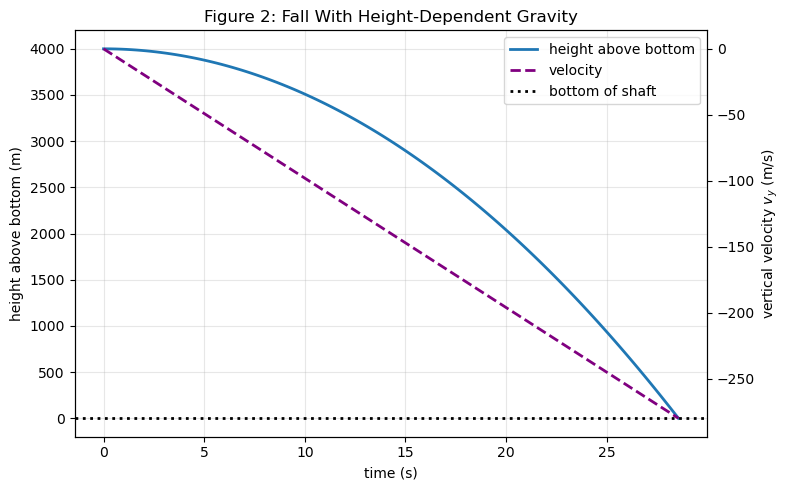

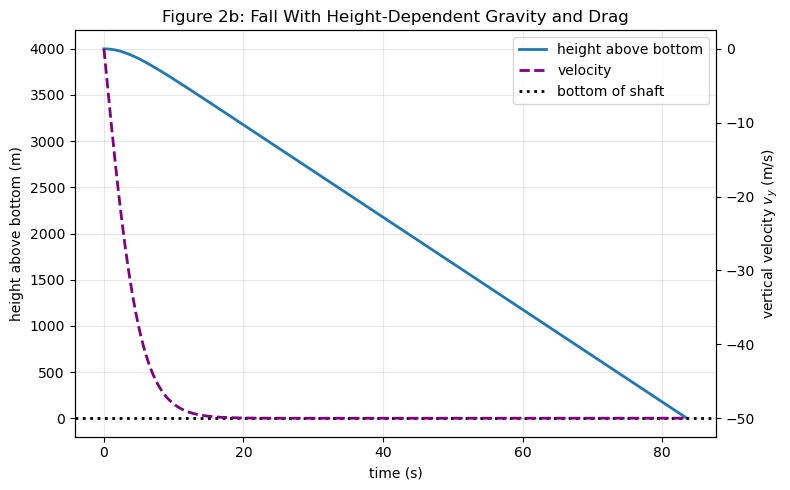

In [4]:
def variable_g_from_y(y: float | np.ndarray) -> float | np.ndarray:
    """
    Gravity inside a constant-density Earth.
    y is measured relative to the surface, so r = R_earth + y.
    """
    r = R_earth + y
    return g0 * r / R_earth


def variable_g_rhs(t: float, state: ArrayLike, alpha: float = 0.0, gamma: float = 2.0) -> list[float]:
    """
    Vertical fall with height-dependent gravity and optional drag.
    state[0] = y, where y = 0 at surface and y < 0 below surface.
    """
    y, vy = state
    ay = -variable_g_from_y(y) + drag_acceleration(vy, alpha, gamma)
    return [vy, ay]


def solve_vertical_fall(alpha: float = 0.0, gamma: float = 2.0):
    """Helper function so I can easily compare the no-drag and drag cases."""
    return solve_ivp(
        variable_g_rhs,
        t_span=(0.0, 400.0),
        y0=[0.0, 0.0],
        max_step=0.25,
        events=hit_bottom_event,
        rtol=1e-9,
        atol=1e-11,
        args=(alpha, gamma),
    )

sol_variable_g = solve_vertical_fall(alpha=0.0, gamma=gamma_drag)
sol_variable_g_drag = solve_vertical_fall(alpha=alpha_terminal, gamma=gamma_drag)

time_variable_g = sol_variable_g.t_events[0][0]
time_variable_g_drag = sol_variable_g_drag.t_events[0][0]

fig, ax_height = plt.subplots(figsize=(8, 5))
ax_speed = ax_height.twinx()

height_above_bottom = sol_variable_g.y[0] + shaft_depth
height_line = ax_height.plot(sol_variable_g.t, height_above_bottom, linewidth=2, label="height above bottom")
velocity_line = ax_speed.plot(sol_variable_g.t, sol_variable_g.y[1], linewidth=2, linestyle="--", label="velocity", color='purple')
bottom_line = ax_height.axhline(0.0, linestyle=":", linewidth=2, label="bottom of shaft", color='black')

ax_height.set_title("Figure 2: Fall With Height-Dependent Gravity")
ax_height.set_xlabel("time (s)")
ax_height.set_ylabel("height above bottom (m)")
ax_speed.set_ylabel("vertical velocity $v_y$ (m/s)")
ax_height.grid(True, alpha=0.3)

lines = height_line + velocity_line + [bottom_line]
labels = [line.get_label() for line in lines]
ax_height.legend(lines, labels, loc="best")
fig.tight_layout()

fig, ax_height_drag = plt.subplots(figsize=(8, 5))
ax_speed_drag = ax_height_drag.twinx()

height_above_bottom_drag = sol_variable_g_drag.y[0] + shaft_depth
height_line_drag = ax_height_drag.plot(sol_variable_g_drag.t, height_above_bottom_drag, linewidth=2, label="height above bottom")
velocity_line_drag = ax_speed_drag.plot(sol_variable_g_drag.t, sol_variable_g_drag.y[1], linewidth=2, linestyle="--", label="velocity", color='purple')
bottom_line_drag = ax_height_drag.axhline(0.0, linestyle=":", linewidth=2, label="bottom of shaft", color='black')

ax_height_drag.set_title("Figure 2b: Fall With Height-Dependent Gravity and Drag")
ax_height_drag.set_xlabel("time (s)")
ax_height_drag.set_ylabel("height above bottom (m)")
ax_speed_drag.set_ylabel("vertical velocity $v_y$ (m/s)")
ax_height_drag.grid(True, alpha=0.3)

lines_drag = height_line_drag + velocity_line_drag + [bottom_line_drag]
labels_drag = [line.get_label() for line in lines_drag]
ax_height_drag.legend(lines_drag, labels_drag, loc="best")
fig.tight_layout()

print(f"Constant-g analytic time:       {analytic_time:.3f} s")
print(f"Variable-g no-drag time:        {time_variable_g:.3f} s")
print(f"Variable-g with-drag time:      {time_variable_g_drag:.3f} s")
print(f"Change from variable g only:    {time_variable_g - analytic_time:.5f} s")
print(f"Additional change due to drag:  {time_variable_g_drag - time_variable_g:.3f} s")
print(f"Impact speed without drag:      {sol_variable_g.y_events[0][0][1]:.3f} m/s")
print(f"Impact speed with drag:         {sol_variable_g_drag.y_events[0][0][1]:.3f} m/s")

## Part 3: The Coriolis Force

Since the Earth is rotating, there is a Coriolis force on the test mass as it falls.
The force can be quite large.
For example, imagine the mine shaft is on the Earth's equator and pointed towards
the Earth's center.
The equator rotates at about half a kilometer per second.
So once the test mass has fallen for some time, it will bump into the wall,
unless the shaft is very wide.
The Coriolis force $\vec{F_c}$ is:

$$
 \vec{F_c} = -2m \, \left( \vec{\Omega} \times \vec{v} \right)
 \tag{3}
$$

where $\vec{\Omega}$ is the Earth's rotation rate for a vector along $\hat{z}$ and $m$ is the mass of the object (1 kg for the test mass in this case).
For a mine shaft on the equator, we might pick a right-handed coordinate system
with the $\hat{x}$ axis along the East, $\hat{y}$ down into the mine shaft,
and $\hat{z}$ along the North.
This implies the component of the force are:

\begin{equation}
        F_{c_x} = + 2m \, \Omega v_y     \tag{4}
\end{equation}
\begin{equation}
        F_{c_y} = - 2m \, \Omega v_x     \tag{5}
\end{equation}
\begin{equation}
        F_{c_z} = 0     \tag{6}
\end{equation}

1. Extend and update your differential equations of motion 
                to include the Coriolis force. You will need to add a Coriolis
                acceleration term to your equation for the depth coordinate (remember, $F=ma$),
                and additionally, start tracking the velocity and position 
                in the transverse direction (``side-to-side'' in the shaft).

2. Plot the transverse position of the object as a function of depth, initially assuming $\alpha=0$.
                        That is, both axes will have units of distance. 
                Plot ``dots" every few seconds so that you can see
                how the particle moves over time.
                Note that your depth and transverse axes are likely to have very
                different length scales.
                The depth will have a range of 4 km,
   while the transverse direction is about 5m.       
                In your report, this should be **Figure 3**.                

3. If the mine shaft is 5m wide, and you drop the test mass 
                        from the center, does the test mass reach the bottom?
                Or does it bump into the wall first?

4. Now turn drag back on. Does drag make any difference here?




Bottom time with Coriolis and no drag: 28.558 s
Eastward deflection at bottom, no drag: 5.538 m
Bottom time with Coriolis and drag:    83.545 s
Eastward deflection at bottom, drag:    2.800 m
Wall hit time with no drag:             21.907 s
Depth at wall hit with no drag:         2353.866 m
Wall hit time with drag:                75.457 s
Depth at wall hit with drag:            3595.716 m


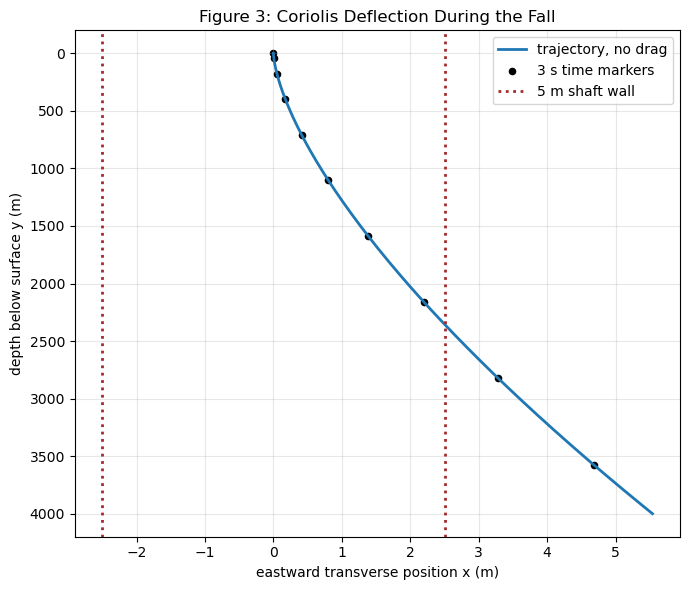

In [5]:
def coriolis_rhs(t: float, state: ArrayLike, alpha: float = 0.0, gamma: float = 2.0) -> list[float]:
    """
    Motion in a mine shaft at the equator.
    x is eastward transverse motion, y is depth downward into the shaft.
    state = [x, y, vx, vy]
    """
    x, y, vx, vy = state
    r = R_earth - y
    g_here = g0 * r / R_earth

    speed = np.sqrt(vx**2 + vy**2)
    if speed == 0:
        drag_x = 0.0
        drag_y = 0.0
    else:
        drag_magnitude = alpha * speed**gamma
        drag_x = -drag_magnitude * vx / speed
        drag_y = -drag_magnitude * vy / speed

    ax = 2 * Omega_earth * vy + drag_x
    ay = g_here - 2 * Omega_earth * vx + drag_y
    return [vx, vy, ax, ay]


def hit_depth_event(t: float, state: ArrayLike, *args) -> float:
    """Event function that becomes zero when the depth is shaft_depth."""
    return state[1] - shaft_depth

hit_depth_event.terminal = True
hit_depth_event.direction = 1

sol_coriolis = solve_ivp(
    coriolis_rhs,
    t_span=(0.0, 400.0),
    y0=[0.0, 0.0, 0.0, 0.0],
    max_step=0.1,
    dense_output=True,
    events=hit_depth_event,
    rtol=1e-9,
    atol=1e-11,
    args=(0.0, gamma_drag),
)

sol_coriolis_drag = solve_ivp(
    coriolis_rhs,
    t_span=(0.0, 400.0),
    y0=[0.0, 0.0, 0.0, 0.0],
    max_step=0.1,
    dense_output=True,
    events=hit_depth_event,
    rtol=1e-9,
    atol=1e-11,
    args=(alpha_terminal, gamma_drag),
)

t_hit_coriolis = sol_coriolis.t_events[0][0]
t_hit_coriolis_drag = sol_coriolis_drag.t_events[0][0]

t_dots = np.arange(0.0, t_hit_coriolis, 3.0)
states_dots = sol_coriolis.sol(t_dots)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(sol_coriolis.y[0], sol_coriolis.y[1], linewidth=2, label="trajectory, no drag")
ax.scatter(states_dots[0], states_dots[1], s=20, label="3 s time markers", color='black')
ax.axvline(2.5, linestyle=":", linewidth=2, label="5 m shaft wall", color="brown")
ax.axvline(-2.5, linestyle=":", linewidth=2, color='brown')

ax.set_title("Figure 3: Coriolis Deflection During the Fall")
ax.set_xlabel("eastward transverse position x (m)")
ax.set_ylabel("depth below surface y (m)")
ax.grid(True, alpha=0.3)
ax.invert_yaxis()
ax.legend(loc="best")
fig.tight_layout()

x_bottom = sol_coriolis.y_events[0][0][0]
x_bottom_drag = sol_coriolis_drag.y_events[0][0][0]

# Find the first time it hits a wall of a 5 m wide shaft.
def wall_event(t: float, state: ArrayLike, *args) -> float:
    return 2.5 - np.abs(state[0])

wall_event.terminal = True
wall_event.direction = -1

sol_wall = solve_ivp(
    coriolis_rhs,
    t_span=(0.0, 400.0),
    y0=[0.0, 0.0, 0.0, 0.0],
    max_step=0.1,
    events=wall_event,
    rtol=1e-9,
    atol=1e-11,
    args=(0.0, gamma_drag),
)

sol_wall_drag = solve_ivp(
    coriolis_rhs,
    t_span=(0.0, 400.0),
    y0=[0.0, 0.0, 0.0, 0.0],
    max_step=0.1,
    events=wall_event,
    rtol=1e-9,
    atol=1e-11,
    args=(alpha_terminal, gamma_drag),
)

print(f"Bottom time with Coriolis and no drag: {t_hit_coriolis:.3f} s")
print(f"Eastward deflection at bottom, no drag: {x_bottom:.3f} m")
print(f"Bottom time with Coriolis and drag:    {t_hit_coriolis_drag:.3f} s")
print(f"Eastward deflection at bottom, drag:    {x_bottom_drag:.3f} m")
print(f"Wall hit time with no drag:             {sol_wall.t_events[0][0]:.3f} s")
print(f"Depth at wall hit with no drag:         {sol_wall.y_events[0][0][1]:.3f} m")
print(f"Wall hit time with drag:                {sol_wall_drag.t_events[0][0]:.3f} s")
print(f"Depth at wall hit with drag:            {sol_wall_drag.y_events[0][0][1]:.3f} m")

## Part 4: An infinitely deep mine


Now, let us consider the theoretical case of an infinitely deep mine -- that is,
a tunnel which traverses the full diameter of the Earth.
For convenience, imagine the tunnel goes from pole-to-pole,
such that $\vec{\Omega} \times \vec{v} = 0$, and the Coriolis force
can be neglected, as well as the drag force.

Additionally, continue assuming a constant density Earth.

1. Again, plot the depth and velocity as a function of time.
               (Be careful with the meaning of $y$, as the particle can theoretically
                traverse fully through to the other side of the Earth.)
                Comment on what you see in the graph.       
                In your notebook, label this figure clearly as **Figure 4**.                

2. How long will it take for the object to reach the other side? 
                At what time does the object reach the center of the Earth,
                and at what speed?

3. How does this ``crossing-time" compare to the orbital period, where you assume
                the object is on a circular orbit, in centripetal balance
                with the attractive force of the gravity.
                \begin{equation}
                        \frac{v^2}{R} = \frac{GM}{R^2}   \tag{7}
                \end{equation}
                gives the orbital speed $v$ for a given Earth radius $R$ and 
                Earth mass $M$.





Time to center:               21.110 min
Speed at center:              7.910 km/s
Time to other side:           42.219 min
Full tunnel oscillation time: 84.438 min
Circular orbital period:      84.490 min
Ratio tunnel period / orbit period = 0.99939


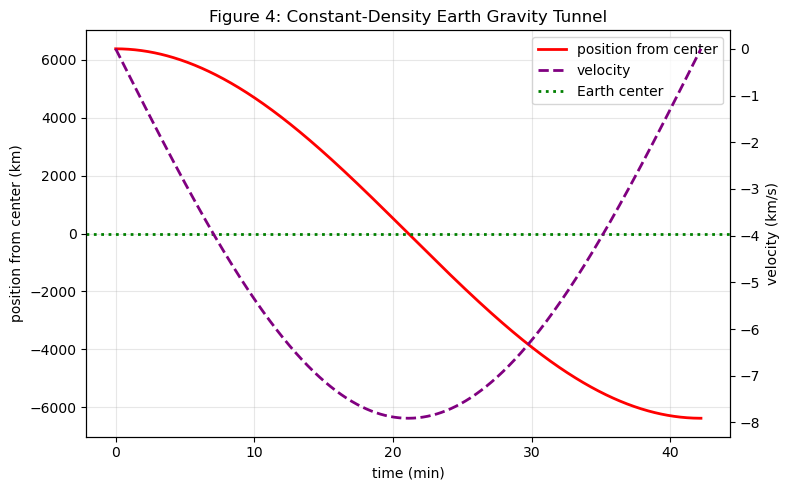

In [6]:
omega_tunnel = np.sqrt(g0 / R_earth)
period_tunnel = 2 * np.pi / omega_tunnel
center_time = np.pi / (2 * omega_tunnel)
other_side_time = np.pi / omega_tunnel
center_speed = omega_tunnel * R_earth


def uniform_earth_tunnel_rhs(t: float, state: ArrayLike) -> list[float]:
    """
    Pole-to-pole tunnel through a constant-density Earth.
    s is position measured from Earth's center. s=R is the starting surface.
    """
    s, v = state
    a = -omega_tunnel**2 * s
    return [v, a]


def center_crossing_event(t: float, state: ArrayLike, *args) -> float:
    return state[0]

center_crossing_event.terminal = False
center_crossing_event.direction = -1


def other_side_event(t: float, state: ArrayLike, *args) -> float:
    return state[0] + R_earth

other_side_event.terminal = True
other_side_event.direction = -1

t_eval_tunnel = np.linspace(0, other_side_time, 1000)
sol_tunnel = solve_ivp(
    uniform_earth_tunnel_rhs,
    t_span=(0.0, other_side_time),
    y0=[R_earth, 0.0],
    t_eval=t_eval_tunnel,
    events=[center_crossing_event, other_side_event],
    rtol=1e-10,
    atol=1e-8,
)

fig, ax_position = plt.subplots(figsize=(8, 5))
ax_velocity = ax_position.twinx()

position_line = ax_position.plot(sol_tunnel.t / 60, sol_tunnel.y[0] / 1e3, linewidth=2, label="position from center", color="red")
velocity_line = ax_velocity.plot(sol_tunnel.t / 60, sol_tunnel.y[1] / 1e3, linewidth=2, linestyle="--", label="velocity", color='purple')
center_line = ax_position.axhline(0.0, linestyle=":", linewidth=2, label="Earth center", color='green')

ax_position.set_title("Figure 4: Constant-Density Earth Gravity Tunnel")
ax_position.set_xlabel("time (min)")
ax_position.set_ylabel("position from center (km)")
ax_velocity.set_ylabel("velocity (km/s)")
ax_position.grid(True, alpha=0.3)

lines = position_line + velocity_line + [center_line]
labels = [line.get_label() for line in lines]
ax_position.legend(lines, labels, loc="best")
fig.tight_layout()

orbital_speed_surface = np.sqrt(G * M_earth / R_earth)
orbital_period_surface = 2 * np.pi * R_earth / orbital_speed_surface

print(f"Time to center:               {center_time / 60:.3f} min")
print(f"Speed at center:              {center_speed / 1e3:.3f} km/s")
print(f"Time to other side:           {other_side_time / 60:.3f} min")
print(f"Full tunnel oscillation time: {period_tunnel / 60:.3f} min")
print(f"Circular orbital period:      {orbital_period_surface / 60:.3f} min")
print(f"Ratio tunnel period / orbit period = {period_tunnel / orbital_period_surface:.5f}")

The Figure 4 motion is simple harmonic motion. The mass speeds up until it reaches the center of Earth, then slows down as it climbs toward the opposite surface. The time to the other side is one half of the full oscillation period, and the full oscillation period is essentially the same as the circular orbital period at Earth's surface. The small difference in the printed ratio comes from using the rounded $g_0=9.81$ m/s$^2$ rather than exactly $GM/R^2$.

## Part 5: A non-uniform Earth

Finally, let us consider the case of a non-uniform Earth, and continue assuming we have no drag. We know from geology
that the density increases towards the center.
It rises from about 2-3 g/cm$^3$ near the surface, to more like 13 near the center.
A simple model for the density $\rho$ as a function of distance from the center of the Earth $r$ is:

$$
\rho(r) = \rho_n \left( 1 - \frac{r^2}{R_{\oplus}^2} \right)^n   \tag{8}
$$

where $n$ is some exponent, and $\rho_n$ is a normalizing constant.
The case of $n=0$ is the constant density Earth, while $n=2$ is closer to the real value.
Note that the total mass of the Earth, $M$, must be conserved.
Since the mass is the volume integral over the density:

\begin{equation}
        M = \int_V \rho(r) dV = \int_0^{2\pi} \int_0^{\pi} \int_0^{R_{\oplus}} \rho(r) r^2 \sin \phi \, dr \, d\phi \,d\theta = 4 \pi \int_0^{R_{\oplus}} \rho(r) r^2 \, dr
        \tag{9}
\end{equation}

you will need to recompute the density constant $\rho_n$ for each case of $n>0$,
You can use the `quad` integrator for this.
Note that the analytic solution is straightforward to do by hand for $n=0$,
and still manageable for $n=1,2$.
You might consider doing that integral to make sure your method is right, 
and then you can be confident for $n>0$.

1.  Plot the normalized density profile (that is, set $\rho_n=1$) as a function of radius for $n=0, 1, 2, 9$.            
              Put them all on the same plot, with a clear legend.       
              In your notebook, label this figure clearly as **Figure 5**.

2. Now, plot the force profile as a function of radius for $n=0, 1, 2, 9$.         
                This step will show you if your normalization factor $\rho_n$
                is correct, because the surface force must be the same for all $n$.       
              In your notebook, label this figure clearly as **Figure 6**.                

3. Then, plot the position and velocity as a function of time for $n=0, 1, 2, 9$
              as you did in Figure 1/2.         
              In your notebook, label this figure clearly as **Figure 7**.              

4. For $n=0, 1, 2, 9$, compute the time to reach the center, 
                and the speed achieved there.





### Part 5, Section A (Density)

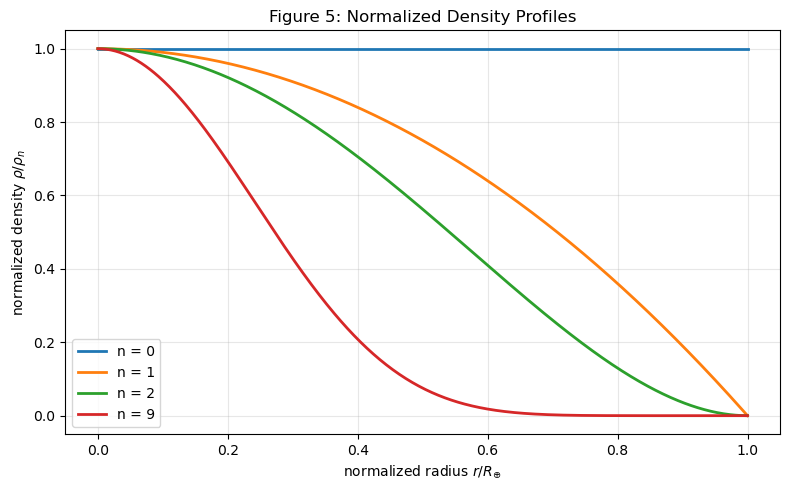

In [7]:
def normalized_density_profile(r: ArrayLike, n: int, R: float = R_earth) -> np.ndarray:
    """Density shape with rho_n set equal to 1."""
    r = np.asarray(r)
    return (1 - r**2 / R**2)**n

n_values = [0, 1, 2, 9]
r_plot = np.linspace(0.0, R_earth, 600)

fig, ax = plt.subplots(figsize=(8, 5))
for n in n_values:
    ax.plot(r_plot / R_earth, normalized_density_profile(r_plot, n), linewidth=2, label=f"n = {n}")

ax.set_title("Figure 5: Normalized Density Profiles")
ax.set_xlabel(r"normalized radius $r/R_{\oplus}$")
ax.set_ylabel(r"normalized density $\rho/\rho_n$")
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
fig.tight_layout()

### Part 5, Section B (Forces)

n =  0: rho_n =   5494.867 kg/m^3, surface g = 9.79812 m/s^2
n =  1: rho_n =  13737.169 kg/m^3, surface g = 9.79812 m/s^2
n =  2: rho_n =  24040.045 kg/m^3, surface g = 9.79812 m/s^2
n =  9: rho_n = 135545.121 kg/m^3, surface g = 9.79812 m/s^2


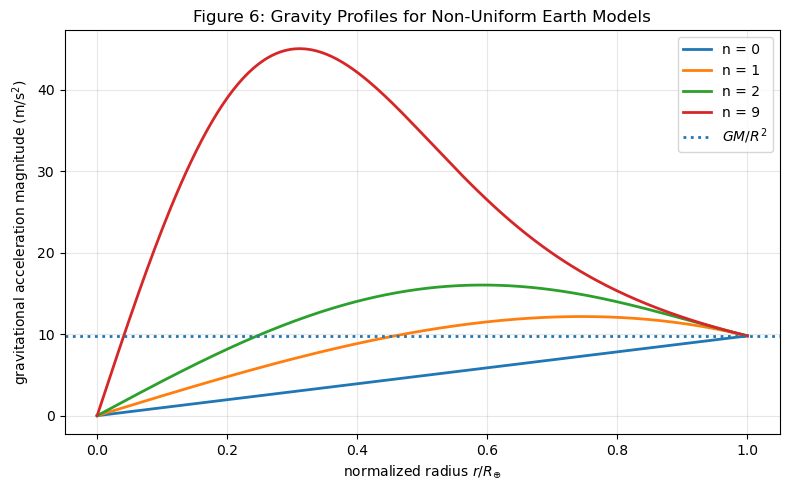

In [8]:
def density_normalization(n: int, M: float = M_earth, R: float = R_earth) -> float:
    """Find rho_n so the density integrates to the total mass M."""
    integral, error = quad(lambda rp: (1 - rp**2 / R**2)**n * rp**2, 0.0, R, epsabs=0.0, epsrel=1e-10)
    return M / (4 * np.pi * integral)


def enclosed_mass(r: float, n: int, M: float = M_earth, R: float = R_earth) -> float:
    """Mass inside radius r for the non-uniform density model."""
    rho_n = density_normalization(n, M=M, R=R)
    integral, error = quad(lambda rp: rho_n * (1 - rp**2 / R**2)**n * rp**2, 0.0, r, epsabs=0.0, epsrel=1e-8)
    return 4 * np.pi * integral


def gravitational_acceleration_radius(r: float | np.ndarray, n: int, M: float = M_earth, R: float = R_earth) -> float | np.ndarray:
    """Magnitude of gravitational acceleration at radius r."""
    r_array = np.atleast_1d(np.asarray(r, dtype=float))
    g_values = np.zeros_like(r_array, dtype=float)
    positive = r_array > 0
    for index in np.where(positive)[0]:
        ri = float(r_array[index])
        g_values[index] = G * enclosed_mass(ri, n, M=M, R=R) / ri**2
    if np.isscalar(r):
        return float(g_values[0])
    return g_values

r_force = np.linspace(0.0, R_earth, 250)

fig, ax = plt.subplots(figsize=(8, 5))
for n in n_values:
    g_force = gravitational_acceleration_radius(r_force, n)
    ax.plot(r_force / R_earth, g_force, linewidth=2, label=f"n = {n}")

ax.axhline(G * M_earth / R_earth**2, linestyle=":", linewidth=2, label=r"$GM/R^2$")
ax.set_title("Figure 6: Gravity Profiles for Non-Uniform Earth Models")
ax.set_xlabel(r"normalized radius $r/R_{\oplus}$")
ax.set_ylabel(r"gravitational acceleration magnitude (m/s$^2$)")
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
fig.tight_layout()

for n in n_values:
    rho_n_value = density_normalization(n)
    surface_g = gravitational_acceleration_radius(R_earth, n)
    print(f"n = {n:2d}: rho_n = {rho_n_value:10.3f} kg/m^3, surface g = {surface_g:.5f} m/s^2")

### Part 5, Section C (Equations of Motion)

n =  0: time to center =  21.122 min, center speed =  7.905 km/s
n =  1: time to center =  18.275 min, center speed = 10.458 km/s
n =  2: time to center =  17.251 min, center speed = 12.183 km/s
n =  9: time to center =  15.730 min, center speed = 18.371 km/s


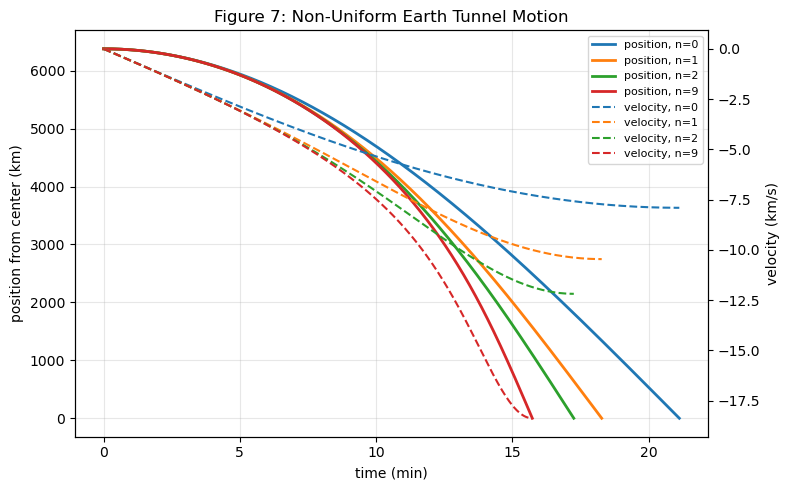

In [9]:
def tunnel_acceleration_nonuniform(s: float, n: int, M: float = M_earth, R: float = R_earth) -> float:
    """
    Signed acceleration for a straight tunnel through the center.
    s is position measured from the center; positive s means one side of Earth.
    """
    r = abs(s)
    if r < 1.0:
        rho_center = density_normalization(n, M=M, R=R)
        return -(4 * np.pi * G * rho_center / 3) * s
    return -G * enclosed_mass(r, n, M=M, R=R) * np.sign(s) / r**2


def nonuniform_tunnel_rhs(t: float, state: ArrayLike, n: int) -> list[float]:
    s, v = state
    return [v, tunnel_acceleration_nonuniform(s, n)]


def make_center_event_nonuniform(t: float, state: ArrayLike, *args) -> float:
    return state[0]

make_center_event_nonuniform.terminal = True
make_center_event_nonuniform.direction = -1

nonuniform_solutions = {}
center_times = {}
center_speeds = {}

fig, ax_position = plt.subplots(figsize=(8, 5))
ax_velocity = ax_position.twinx()

for n in n_values:
    sol = solve_ivp(
        nonuniform_tunnel_rhs,
        t_span=(0.0, 5000.0),
        y0=[R_earth, 0.0],
        max_step=2.0,
        dense_output=True,
        events=make_center_event_nonuniform,
        rtol=1e-8,
        atol=1e-8,
        args=(n,),
    )
    nonuniform_solutions[n] = sol
    center_times[n] = sol.t_events[0][0]
    center_speeds[n] = abs(sol.y_events[0][0][1])

    t_sample = np.linspace(0.0, center_times[n], 500)
    y_sample = sol.sol(t_sample)
    ax_position.plot(t_sample / 60, y_sample[0] / 1e3, linewidth=2, label=f"position, n={n}")
    ax_velocity.plot(t_sample / 60, y_sample[1] / 1e3, linewidth=1.5, linestyle="--", label=f"velocity, n={n}")

ax_position.set_title("Figure 7: Non-Uniform Earth Tunnel Motion")
ax_position.set_xlabel("time (min)")
ax_position.set_ylabel("position from center (km)")
ax_velocity.set_ylabel("velocity (km/s)")
ax_position.grid(True, alpha=0.3)

lines_position, labels_position = ax_position.get_legend_handles_labels()
lines_velocity, labels_velocity = ax_velocity.get_legend_handles_labels()
ax_position.legend(lines_position + lines_velocity, labels_position + labels_velocity, fontsize=8, loc="best")
fig.tight_layout()

for n in n_values:
    print(f"n = {n:2d}: time to center = {center_times[n] / 60:7.3f} min, center speed = {center_speeds[n] / 1e3:6.3f} km/s")

## Part 6: A Lunar Mine Shaft


Finally, with all of the framework in place, consider the case where the
the mine shaft is instead dug on the moon.

1. Compute the travel time to the center of the moon
                in case we dig a pole-to-pole mine shaft,
                so that we can again avoid the Coriolis force, though
                on the moon this force is very small. No drag force either,
   which is actually realistic for the moon!
3. What is the density (if you asssume a constant density) 
                of the moon compared to that of earth? 
4. How does the fall/orbit time depend on density? See if you can discover a 
        relationship between the density and the fall time. You should think beyond strictly linear 
        relationships.



This problem can actually be
done on paper, and then you can compare the answer with that for the homogenous earth
you did in Part 4.


In [10]:
def center_fall_time_constant_density(M: float, R: float) -> float:
    """Time to fall from the surface to the center through a constant-density sphere."""
    omega = np.sqrt(G * M / R**3)
    return np.pi / (2 * omega)


def mean_density(M: float, R: float) -> float:
    """Average density of a sphere."""
    return M / ((4 / 3) * np.pi * R**3)

moon_center_time = center_fall_time_constant_density(M_moon, R_moon)
earth_center_time_constant_density = center_fall_time_constant_density(M_earth, R_earth)

rho_earth_mean = mean_density(M_earth, R_earth)
rho_moon_mean = mean_density(M_moon, R_moon)

print(f"Earth mean density: {rho_earth_mean:.1f} kg/m^3")
print(f"Moon mean density:  {rho_moon_mean:.1f} kg/m^3")
print(f"Moon density / Earth density = {rho_moon_mean / rho_earth_mean:.3f}")
print(f"Earth time to center, constant density = {earth_center_time_constant_density / 60:.3f} min")
print(f"Moon time to center, constant density  = {moon_center_time / 60:.3f} min")

Earth mean density: 5494.9 kg/m^3
Moon mean density:  3341.8 kg/m^3
Moon density / Earth density = 0.608
Earth time to center, constant density = 21.122 min
Moon time to center, constant density  = 27.085 min


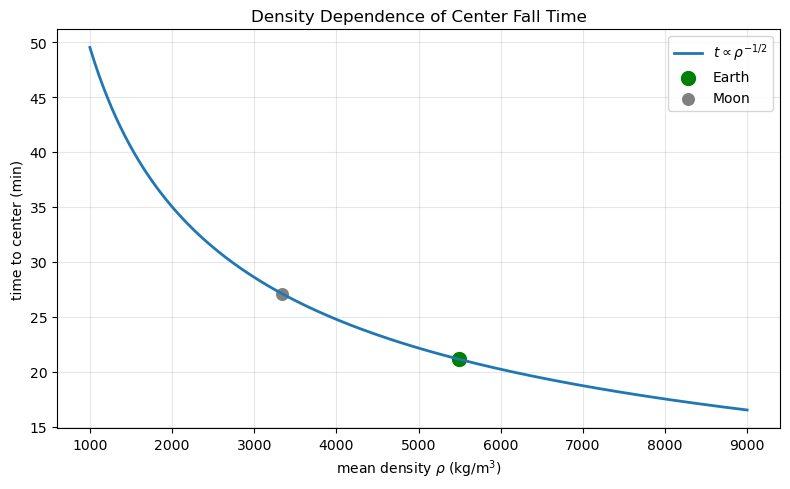

In [11]:
# Exploring the density dependence directly.
# For a constant-density sphere: omega^2 = 4*pi*G*rho/3, so t_center is proportional to 1/sqrt(rho).

density_grid = np.linspace(1000.0, 9000.0, 300)
time_grid = np.sqrt(3 * np.pi / (16 * G * density_grid))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(density_grid, time_grid / 60, linewidth=2, label=r"$t \propto \rho^{-1/2}$")
ax.scatter([rho_earth_mean], [earth_center_time_constant_density / 60], s=100, label="Earth", color='green')
ax.scatter(rho_moon_mean, moon_center_time / 60, s=70, label="Moon", color='grey')

ax.set_title("Density Dependence of Center Fall Time")
ax.set_xlabel(r"mean density $\rho$ (kg/m$^3$)")
ax.set_ylabel("time to center (min)")
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
fig.tight_layout()

In [12]:
predicted_moon_time_from_density = earth_center_time_constant_density * np.sqrt(rho_earth_mean / rho_moon_mean)

print(f"Moon time predicted from density scaling: {predicted_moon_time_from_density / 60:.3f} min")
print(f"Moon time computed from M and R:          {moon_center_time / 60:.3f} min")
print(f"Ratio of Moon time to Earth time:        {moon_center_time / earth_center_time_constant_density:.3f}")
print(f"sqrt(Earth density / Moon density):      {np.sqrt(rho_earth_mean / rho_moon_mean):.3f}")

Moon time predicted from density scaling: 27.085 min
Moon time computed from M and R:          27.085 min
Ratio of Moon time to Earth time:        1.282
sqrt(Earth density / Moon density):      1.282


In [13]:
# The same relationship also connects the gravity-tunnel period to the circular orbit period.
moon_orbit_period = 2 * np.pi * np.sqrt(R_moon**3 / (G * M_moon))
earth_orbit_period = 2 * np.pi * np.sqrt(R_earth**3 / (G * M_earth))

print(f"Moon circular orbit period near surface:  {moon_orbit_period / 60:.3f} min")
print(f"Earth circular orbit period near surface: {earth_orbit_period / 60:.3f} min")
print(f"Moon time to center is one quarter of the full oscillation/orbit period: {moon_center_time / moon_orbit_period:.3f}")

Moon circular orbit period near surface:  108.341 min
Earth circular orbit period near surface: 84.490 min
Moon time to center is one quarter of the full oscillation/orbit period: 0.250


Assuming constant density, the Moon has a lower mean density than Earth, so the fall time is longer. The important relationship is not linear: because the restoring acceleration inside a uniform sphere is proportional to $\rho r$, the angular frequency scales like $\sqrt{\rho}$ and the fall time scales like $1/\sqrt{\rho}$.

## Part 7: Fourier Transforming Orbits

Take the solutions for n=0 and n=9 of the orbits in Part 5 (the inhomogeneous earth) and Fourier Transform them, to see what frequencies (*1/periods*) are dominant in the power spectra. Comment on what you see.

**Hint:** you could take the orbit from the previous integration in Part 5c, but it is useful to increase the integration time and sampling to get more meaningful smooth enough curves. We discussed this in class.

For an example of a spectral analysis of galactic orbits see https://articles.adsabs.harvard.edu/pdf/1982ApJ...252..308B

In [14]:
def solve_nonuniform_orbit_for_fft(n: int, n_periods: float = 6.0, samples: int = 8192):
    """
    Solve a longer non-uniform tunnel orbit with evenly spaced samples for the FFT.
    Let us estimate the full period from four times the fall-to-center time, just cause
    """
    estimated_period = 4 * center_times[n]
    t_eval = np.linspace(0.0, n_periods * estimated_period, samples)
    sol = solve_ivp(
        nonuniform_tunnel_rhs,
        t_span=(0.0, n_periods * estimated_period),
        y0=[R_earth, 0.0],
        t_eval=t_eval,
        rtol=1e-8,
        atol=1e-8,
        args=(n,),
    )
    return sol

sol_fft_n0 = solve_nonuniform_orbit_for_fft(0)
sol_fft_n9 = solve_nonuniform_orbit_for_fft(9)

In [15]:
def compute_power_spectrum(t: np.ndarray, signal: np.ndarray):
    """Return frequency and power spectrum for an evenly sampled signal."""
    dt = t[1] - t[0]
    centered_signal = signal - np.mean(signal)
    amplitude = np.fft.rfft(centered_signal)
    frequency = np.fft.rfftfreq(centered_signal.size, dt)
    power = np.abs(amplitude)**2
    return frequency, power

freq_n0, power_n0 = compute_power_spectrum(sol_fft_n0.t, sol_fft_n0.y[0])
freq_n9, power_n9 = compute_power_spectrum(sol_fft_n9.t, sol_fft_n9.y[0])

# Ignore the zero-frequency term when locating the dominant oscillation.
peak_index_n0 = np.argmax(power_n0[1:]) + 1
peak_index_n9 = np.argmax(power_n9[1:]) + 1

peak_freq_n0 = freq_n0[peak_index_n0]
peak_freq_n9 = freq_n9[peak_index_n9]

print(f"Dominant frequency for n=0: {peak_freq_n0:.6e} Hz")
print(f"Dominant period for n=0:    {1 / peak_freq_n0 / 60:.3f} min")
print(f"Dominant frequency for n=9: {peak_freq_n9:.6e} Hz")
print(f"Dominant period for n=9:    {1 / peak_freq_n9 / 60:.3f} min")

Dominant frequency for n=0: 1.972390e-04 Hz
Dominant period for n=0:    84.500 min
Dominant frequency for n=9: 2.648606e-04 Hz
Dominant period for n=9:    62.926 min


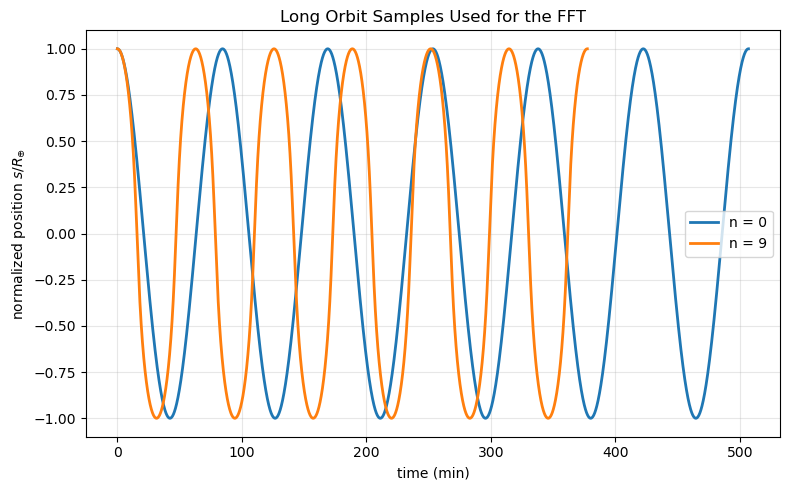

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sol_fft_n0.t / 60, sol_fft_n0.y[0] / R_earth, linewidth=2, label="n = 0")
ax.plot(sol_fft_n9.t / 60, sol_fft_n9.y[0] / R_earth, linewidth=2, label="n = 9")

ax.set_title("Long Orbit Samples Used for the FFT")
ax.set_xlabel("time (min)")
ax.set_ylabel(r"normalized position $s/R_{\oplus}$")
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
fig.tight_layout()

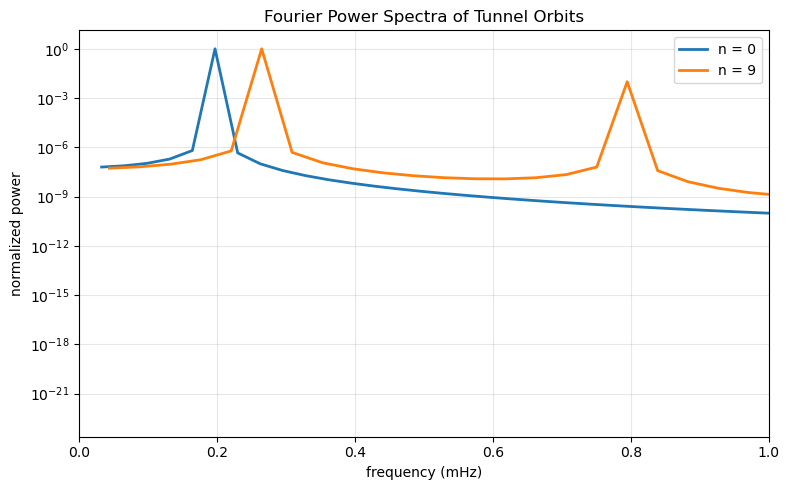

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(freq_n0[1:] * 1e3, power_n0[1:] / np.max(power_n0[1:]), linewidth=2, label="n = 0")
ax.plot(freq_n9[1:] * 1e3, power_n9[1:] / np.max(power_n9[1:]), linewidth=2, label="n = 9")

ax.set_title("Fourier Power Spectra of Tunnel Orbits")
ax.set_xlabel("frequency (mHz)")
ax.set_ylabel("normalized power")
ax.set_xlim(0.0, 1.0)
ax.set_yscale("log")
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
fig.tight_layout()

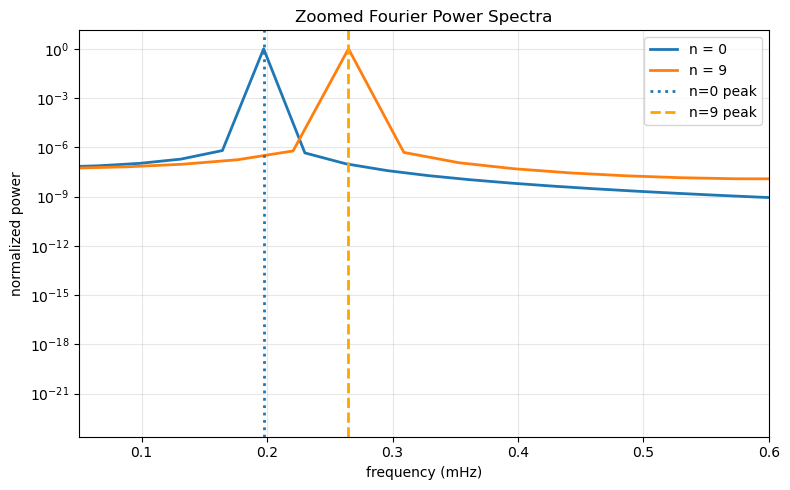

In [18]:
# Zooming in makes the dominant peaks easier to read.
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(freq_n0[1:] * 1e3, power_n0[1:] / np.max(power_n0[1:]), linewidth=2, label="n = 0")
ax.plot(freq_n9[1:] * 1e3, power_n9[1:] / np.max(power_n9[1:]), linewidth=2, label="n = 9")
ax.axvline(peak_freq_n0 * 1e3, linestyle=":", linewidth=2, label="n=0 peak")
ax.axvline(peak_freq_n9 * 1e3, linestyle="--", linewidth=2, label="n=9 peak", color='orange')

ax.set_title("Zoomed Fourier Power Spectra")
ax.set_xlabel("frequency (mHz)")
ax.set_ylabel("normalized power")
ax.set_xlim(0.05, 0.6)
ax.set_yscale("log")
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
fig.tight_layout()

The $n=0$ case is almost a perfect sinusoid because the constant-density Earth gives a perfectly linear restoring force, $a \propto -s$. That means its Fourier spectrum is dominated by one clean frequency. For $n=9$, the density is much more concentrated near the center, so the force law is no longer as close to a single simple-harmonic oscillator over the full radius. This adds extra structure and harmonics to the power spectrum.

Describe what we see here:

The spectra show that the homogeneous model has one very strong fundamental frequency, while the highly non-uniform model spreads more power into additional frequencies. Physically, this happens because the $n=9$ mass distribution changes the shape of the orbit away from a pure sine wave.